In [2]:
# ============================================================
# Association Analysis 실습
# Dataset: Online Retail (UCI ML Repository)
# 파일: Online Retail.xlsx
# 알고리즘: FP-Growth + Apriori
# ============================================================

# [필수 설치]
# pip install pandas openpyxl mlxtend matplotlib seaborn

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

matplotlib.rcParams['font.family'] = 'DejaVu Sans'

In [5]:
# ============================================================
# STEP 1: 데이터 로드
# ============================================================
from pathlib import Path
import urllib.request

print("=" * 60)
print("STEP 1: 데이터 로드")
print("=" * 60)

file_name = "Online_Retail.xlsx"
candidate_paths = [
    Path(file_name),
    Path("./dataset") / file_name,
    Path("../dataset") / file_name,
]
# excel_path = next((p for p in candidate_paths if p.exists()), None)
excel_path = Path(file_name)
# if excel_path is None:
#     url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
#     excel_path = Path(file_name)
#     print(f"파일이 없어 다운로드합니다: {url}")
#     urllib.request.urlretrieve(url, excel_path)

df_raw = pd.read_excel(excel_path, engine="openpyxl")

print(f"\n로드 완료!")
print(f"사용 파일    : {excel_path.resolve()}")
print(f"Shape        : {df_raw.shape}  (행 x 열)")
print(f"컬럼 목록    : {df_raw.columns.tolist()}")
print(f"\n[원본 데이터 샘플 - 상위 5행]")
print(df_raw.head())

STEP 1: 데이터 로드

로드 완료!
사용 파일    : /Users/erickim/Documents/ML_Training/d2_statistic_cluster_associate/Online_Retail.xlsx
Shape        : (541909, 8)  (행 x 열)
컬럼 목록    : ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

[원본 데이터 샘플 - 상위 5행]
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:

In [6]:
# ============================================================
# STEP 2: 데이터 탐색 (EDA)
# ============================================================
print("\n" + "=" * 60)
print("STEP 2: 데이터 탐색 (EDA)")
print("=" * 60)

print(f"\n[결측치 현황]")
print(df_raw.isnull().sum())

print(f"\n[기본 통계]")
print(f"  총 거래 건수     : {df_raw.shape[0]:,}")
print(f"  고유 InvoiceNo   : {df_raw['InvoiceNo'].nunique():,}")
print(f"  고유 상품 수      : {df_raw['Description'].nunique():,}")
print(f"  고유 고객 수      : {df_raw['CustomerID'].nunique():,}")
print(f"  거래 국가 수      : {df_raw['Country'].nunique():,}")
print(f"  거래 기간         : {df_raw['InvoiceDate'].min()} ~ {df_raw['InvoiceDate'].max()}")

# 취소 주문 현황 확인
cancel_count = df_raw[df_raw['InvoiceNo'].astype(str).str.startswith('C')].shape[0]
print(f"\n  취소 주문 건수   : {cancel_count:,} (InvoiceNo 'C' 시작)")


STEP 2: 데이터 탐색 (EDA)

[결측치 현황]
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

[기본 통계]
  총 거래 건수     : 541,909
  고유 InvoiceNo   : 25,900
  고유 상품 수      : 4,223
  고유 고객 수      : 4,372
  거래 국가 수      : 38
  거래 기간         : 2010-12-01 08:26:00 ~ 2011-12-09 12:50:00

  취소 주문 건수   : 9,288 (InvoiceNo 'C' 시작)


In [7]:
# ============================================================
# STEP 3: 데이터 전처리
# ============================================================
print("\n" + "=" * 60)
print("STEP 3: 데이터 전처리")
print("=" * 60)

df = df_raw.copy()

# 3-1. 결측치 제거
before = len(df)
df.dropna(subset=['InvoiceNo', 'Description', 'CustomerID'], inplace=True)
print(f"결측치 제거     : {before:,} → {len(df):,} 행 ({before - len(df):,} 제거)")

# 3-2. 취소 주문 제거
before = len(df)
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print(f"취소 주문 제거  : {before:,} → {len(df):,} 행 ({before - len(df):,} 제거)")

# 3-3. 수량/단가 이상값 제거
before = len(df)
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
print(f"이상값 제거     : {before:,} → {len(df):,} 행 ({before - len(df):,} 제거)")

# 3-4. Description 정제 (공백 제거, 대문자화)
df['Description'] = df['Description'].str.strip().str.upper()

print(f"\n전처리 완료 → 최종 {len(df):,} 행 사용")


STEP 3: 데이터 전처리
결측치 제거     : 541,909 → 406,829 행 (135,080 제거)
취소 주문 제거  : 406,829 → 397,924 행 (8,905 제거)
이상값 제거     : 397,924 → 397,884 행 (40 제거)

전처리 완료 → 최종 397,884 행 사용


In [8]:
# ============================================================
# STEP 4: 트랜잭션 데이터 생성
# ============================================================
print("\n" + "=" * 60)
print("STEP 4: 트랜잭션 데이터 생성")
print("=" * 60)

# InvoiceNo 기준으로 상품 리스트 묶기
basket = df.groupby('InvoiceNo')['Description'].apply(list).reset_index()
basket.columns = ['InvoiceNo', 'Items']
print(basket.head())
print("\n")

transactions = basket['Items'].tolist()
print(f"트랜잭션 수     : {len(transactions):,}")
print(f"평균 상품 수/거래: {sum(len(t) for t in transactions) / len(transactions):.1f}개")
print(f"\n[트랜잭션 샘플 - 상위 3개]")
for i, t in enumerate(transactions[:3]):
    print(f"  [{i+1}] {t[:5]}{'...' if len(t) > 5 else ''}")  # 최대 5개만 출력


STEP 4: 트랜잭션 데이터 생성
   InvoiceNo                                              Items
0     536365  [WHITE HANGING HEART T-LIGHT HOLDER, WHITE MET...
1     536366  [HAND WARMER UNION JACK, HAND WARMER RED POLKA...
2     536367  [ASSORTED COLOUR BIRD ORNAMENT, POPPY'S PLAYHO...
3     536368  [JAM MAKING SET WITH JARS, RED COAT RACK PARIS...
4     536369                         [BATH BUILDING BLOCK WORD]


트랜잭션 수     : 18,532
평균 상품 수/거래: 21.5개

[트랜잭션 샘플 - 상위 3개]
  [1] ['WHITE HANGING HEART T-LIGHT HOLDER', 'WHITE METAL LANTERN', 'CREAM CUPID HEARTS COAT HANGER', 'KNITTED UNION FLAG HOT WATER BOTTLE', 'RED WOOLLY HOTTIE WHITE HEART.']...
  [2] ['HAND WARMER UNION JACK', 'HAND WARMER RED POLKA DOT']
  [3] ['ASSORTED COLOUR BIRD ORNAMENT', "POPPY'S PLAYHOUSE BEDROOM", "POPPY'S PLAYHOUSE KITCHEN", 'FELTCRAFT PRINCESS CHARLOTTE DOLL', 'IVORY KNITTED MUG COSY']...


In [9]:
# ============================================================
# STEP 5: One-Hot Encoding
# ============================================================
print("\n" + "=" * 60)
print("STEP 5: One-Hot Encoding (TransactionEncoder)")
print("=" * 60)

te = TransactionEncoder()
te_array = te.fit_transform(transactions)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

print(f"인코딩 후 Shape : {df_encoded.shape}  (트랜잭션 수 x 고유 품목 수)")
print(f"고유 품목 수    : {len(te.columns_):,}")
print(df_encoded.head())


STEP 5: One-Hot Encoding (TransactionEncoder)
인코딩 후 Shape : (18532, 3866)  (트랜잭션 수 x 고유 품목 수)
고유 품목 수    : 3,866
   10 COLOUR SPACEBOY PEN  12 COLOURED PARTY BALLOONS  \
0                   False                       False   
1                   False                       False   
2                   False                       False   
3                   False                       False   
4                   False                       False   

   12 DAISY PEGS IN WOOD BOX  12 EGG HOUSE PAINTED WOOD  \
0                      False                      False   
1                      False                      False   
2                      False                      False   
3                      False                      False   
4                      False                      False   

   12 HANGING EGGS HAND PAINTED  12 IVORY ROSE PEG PLACE SETTINGS  \
0                         False                             False   
1                         False                   

In [10]:
# ============================================================
# STEP 6: 빈발 항목 집합 추출 - FP-Growth
# ============================================================
print("\n" + "=" * 60)
print("STEP 6: 빈발 항목 집합 - FP-Growth")
print("=" * 60)

# ※ 데이터가 크므로 min_support를 너무 낮게 설정하면 오래 걸림
MIN_SUPPORT = 0.02   # 2% — 필요 시 조정

print(f"min_support = {MIN_SUPPORT}  ({MIN_SUPPORT*100:.0f}% 이상 등장한 항목만 추출)")
print("FP-Growth 실행 중...")

frequent_itemsets = fpgrowth(
    df_encoded,
    min_support=MIN_SUPPORT,
    use_colnames=True
)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

print(f"빈발 항목 집합 수 : {len(frequent_itemsets):,}")
print(f"\n[항목 집합 크기별 분포]")
size_dist = frequent_itemsets['length'].value_counts().sort_index()
for size, count in size_dist.items():
    print(f"  {size}-itemset : {count:,}개")

print(f"\n[Support 상위 10개]")
top10 = frequent_itemsets.sort_values('support', ascending=False).head(10).copy()
top10['itemsets'] = top10['itemsets'].apply(lambda x: ', '.join(list(x)))
top10['support'] = top10['support'].map('{:.4f}'.format)
print(top10[['itemsets', 'support', 'length']].to_string(index=False))



STEP 6: 빈발 항목 집합 - FP-Growth
min_support = 0.02  (2% 이상 등장한 항목만 추출)
FP-Growth 실행 중...
빈발 항목 집합 수 : 243

[항목 집합 크기별 분포]
  1-itemset : 207개
  2-itemset : 35개
  3-itemset : 1개

[Support 상위 10개]
                          itemsets support  length
WHITE HANGING HEART T-LIGHT HOLDER  0.1064       1
          REGENCY CAKESTAND 3 TIER  0.0919       1
           JUMBO BAG RED RETROSPOT  0.0863       1
                     PARTY BUNTING  0.0744       1
     ASSORTED COLOUR BIRD ORNAMENT  0.0742       1
           LUNCH BAG RED RETROSPOT  0.0695       1
  SET OF 3 CAKE TINS PANTRY DESIGN  0.0618       1
                           POSTAGE  0.0593       1
           LUNCH BAG  BLACK SKULL.  0.0568       1
   PACK OF 72 RETROSPOT CAKE CASES  0.0555       1


In [11]:
# ============================================================
# STEP 7: 연관 규칙 생성
# ============================================================
print("\n" + "=" * 60)
print("STEP 7: 연관 규칙 생성")
print("=" * 60)

MIN_CONFIDENCE = 0.1   # 10% 이상 Confidence

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=MIN_CONFIDENCE
)

print(f"min_confidence = {MIN_CONFIDENCE}")
print(f"생성된 규칙 수  : {len(rules):,}")

# 문자열 변환 (출력용)
rules['ant_str'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
rules['con_str'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))

print(f"\n[Lift 상위 10개 규칙]")
top_rules = rules.sort_values('lift', ascending=False).head(10).copy()
top_rules_display = top_rules[['ant_str', 'con_str', 'support', 'confidence', 'lift']].copy()
top_rules_display.columns = ['IF', 'THEN', 'Support', 'Confidence', 'Lift']
for col in ['Support', 'Confidence', 'Lift']:
    top_rules_display[col] = top_rules_display[col].map('{:.4f}'.format)
print(top_rules_display.to_string(index=False))


STEP 7: 연관 규칙 생성
min_confidence = 0.1
생성된 규칙 수  : 76

[Lift 상위 10개 규칙]
                                                              IF                                                             THEN Support Confidence    Lift
                                  PINK REGENCY TEACUP AND SAUCER ROSES REGENCY TEACUP AND SAUCER, GREEN REGENCY TEACUP AND SAUCER  0.0210     0.7014 24.0278
ROSES REGENCY TEACUP AND SAUCER, GREEN REGENCY TEACUP AND SAUCER                                   PINK REGENCY TEACUP AND SAUCER  0.0210     0.7209 24.0278
                                 GREEN REGENCY TEACUP AND SAUCER  ROSES REGENCY TEACUP AND SAUCER, PINK REGENCY TEACUP AND SAUCER  0.0210     0.5644 23.9896
 ROSES REGENCY TEACUP AND SAUCER, PINK REGENCY TEACUP AND SAUCER                                  GREEN REGENCY TEACUP AND SAUCER  0.0210     0.8945 23.9896
                                  PINK REGENCY TEACUP AND SAUCER                                  GREEN REGENCY TEACUP AND SAUCER  0.0248     0

In [12]:
# ============================================================
# STEP 8: 지표 해석
# ============================================================
print("\n" + "=" * 60)
print("STEP 8: 핵심 지표 해석")
print("=" * 60)

best = rules.sort_values('lift', ascending=False).iloc[0]
ant = ', '.join(list(best['antecedents']))
con = ', '.join(list(best['consequents']))

print(f"\n[가장 강한 연관 규칙 상세 해석]")
print(f"  규칙       : IF [{ant}]")
print(f"               → THEN [{con}]")
print(f"  Support    : {best['support']:.4f}")
print(f"               전체 거래의 {best['support']*100:.2f}%에서 두 상품이 함께 등장")
print(f"  Confidence : {best['confidence']:.4f}")
print(f"               [{ant}] 구매 시 {best['confidence']*100:.1f}% 확률로 [{con}] 도 구매")
print(f"  Lift       : {best['lift']:.4f}")
print(f"               우연 대비 {best['lift']:.2f}배 많이 함께 구매 (Lift > 1: 양의 연관)")
print(f"  Leverage   : {best['leverage']:.4f}")
print(f"  Conviction : {best['conviction']:.4f}")

print(f"\n  ┌─────────────────────────────────────────────┐")
print(f"  │ Lift > 1  : 양의 연관 (함께 구매 경향 있음) │")
print(f"  │ Lift = 1  : 독립 (연관 없음)                │")
print(f"  │ Lift < 1  : 음의 연관 (서로 기피 경향)      │")
print(f"  └─────────────────────────────────────────────┘")


STEP 8: 핵심 지표 해석

[가장 강한 연관 규칙 상세 해석]
  규칙       : IF [PINK REGENCY TEACUP AND SAUCER]
               → THEN [ROSES REGENCY TEACUP AND SAUCER, GREEN REGENCY TEACUP AND SAUCER]
  Support    : 0.0210
               전체 거래의 2.10%에서 두 상품이 함께 등장
  Confidence : 0.7014
               [PINK REGENCY TEACUP AND SAUCER] 구매 시 70.1% 확률로 [ROSES REGENCY TEACUP AND SAUCER, GREEN REGENCY TEACUP AND SAUCER] 도 구매
  Lift       : 24.0278
               우연 대비 24.03배 많이 함께 구매 (Lift > 1: 양의 연관)
  Leverage   : 0.0202
  Conviction : 3.2516

  ┌─────────────────────────────────────────────┐
  │ Lift > 1  : 양의 연관 (함께 구매 경향 있음) │
  │ Lift = 1  : 독립 (연관 없음)                │
  │ Lift < 1  : 음의 연관 (서로 기피 경향)      │
  └─────────────────────────────────────────────┘



STEP 9: 시각화 생성 중...
시각화 저장 완료 → association_analysis_online_retail_result.png


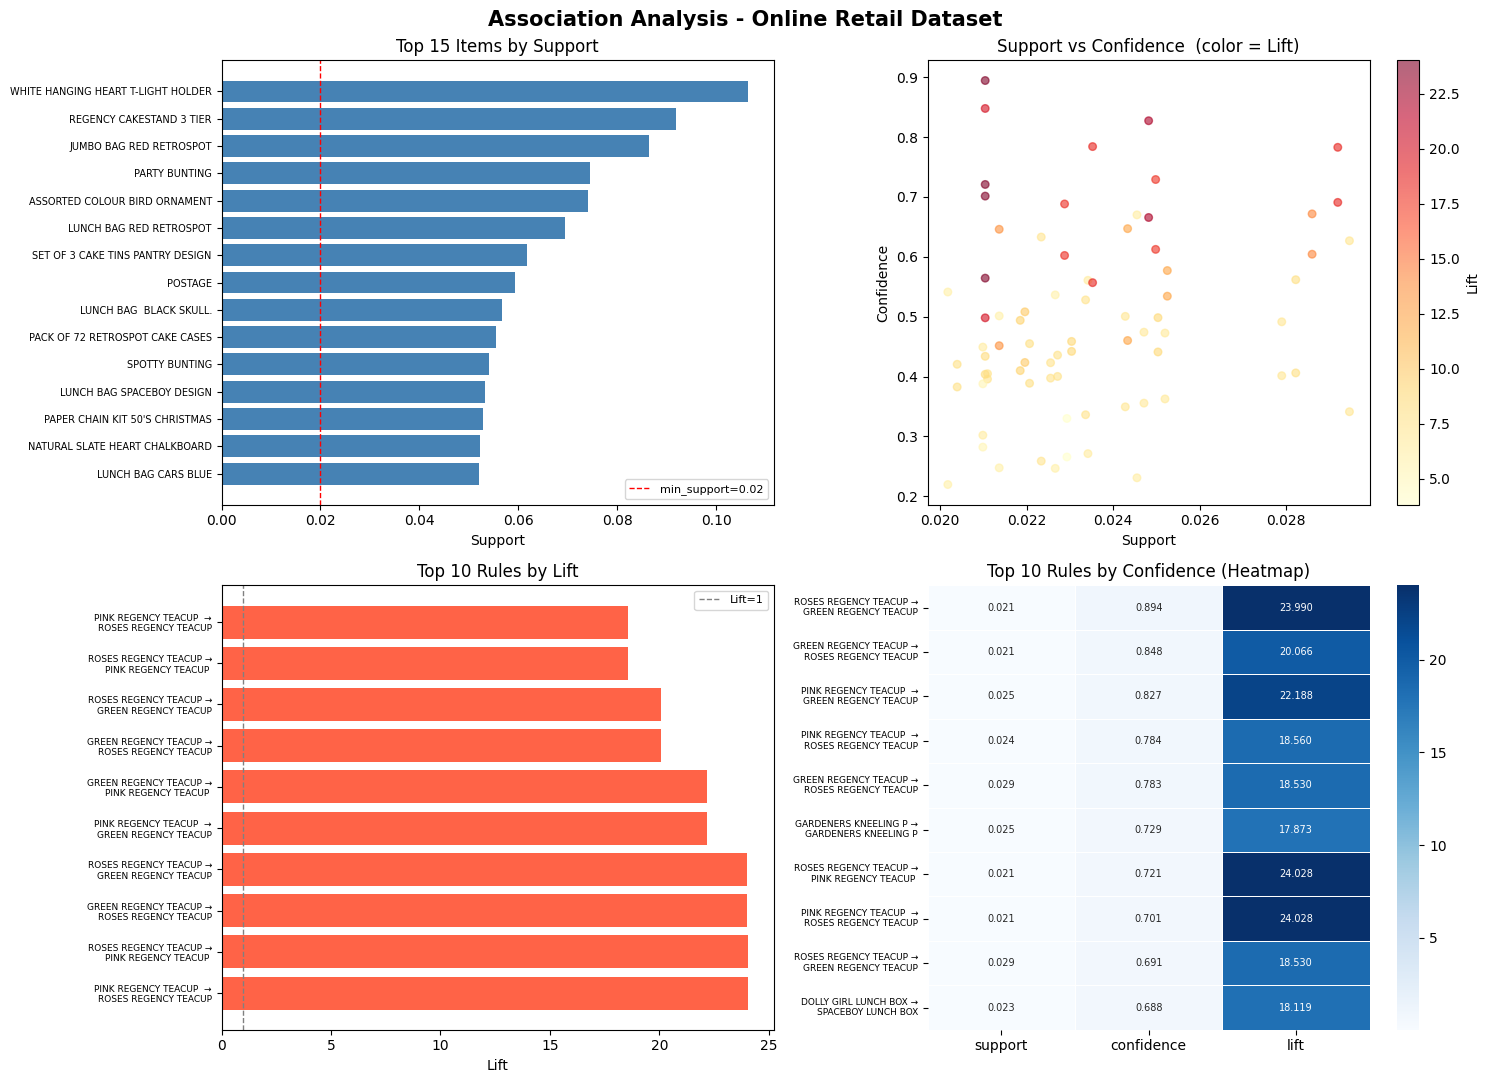


실습 완료!
  · 트랜잭션 수     : 18,532
  · 빈발 항목 집합  : 243개
  · 연관 규칙 수    : 76개


In [13]:
# ============================================================
# STEP 9: 시각화
# ============================================================
print("\n" + "=" * 60)
print("STEP 9: 시각화 생성 중...")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Association Analysis - Online Retail Dataset', fontsize=15, fontweight='bold')

# --- (1) 상위 상품 Support 바 차트 ---
ax1 = axes[0, 0]
top_items = frequent_itemsets[frequent_itemsets['length'] == 1] \
    .sort_values('support', ascending=False).head(15).copy()
item_labels = [', '.join(list(x))[:35] for x in top_items['itemsets']]
ax1.barh(item_labels[::-1], top_items['support'].values[::-1], color='steelblue')
ax1.set_xlabel('Support')
ax1.set_title('Top 15 Items by Support')
ax1.axvline(MIN_SUPPORT, color='red', linestyle='--', linewidth=1,
            label=f'min_support={MIN_SUPPORT}')
ax1.legend(fontsize=8)
ax1.tick_params(axis='y', labelsize=7)

# --- (2) Support vs Confidence 산점도 (color = Lift) ---
ax2 = axes[0, 1]
scatter = ax2.scatter(
    rules['support'], rules['confidence'],
    c=rules['lift'], cmap='YlOrRd', alpha=0.6, s=30
)
plt.colorbar(scatter, ax=ax2, label='Lift')
ax2.set_xlabel('Support')
ax2.set_ylabel('Confidence')
ax2.set_title('Support vs Confidence  (color = Lift)')

# --- (3) Lift 상위 10개 규칙 바 차트 ---
ax3 = axes[1, 0]
top_lift = rules.sort_values('lift', ascending=False).head(10)
rule_labels = [f"{', '.join(list(a))[:20]} →\n{', '.join(list(c))[:20]}"
               for a, c in zip(top_lift['antecedents'], top_lift['consequents'])]
bars = ax3.barh(range(len(rule_labels)), top_lift['lift'].values, color='tomato')
ax3.set_yticks(range(len(rule_labels)))
ax3.set_yticklabels(rule_labels[::-1][::-1], fontsize=6.5)
ax3.set_xlabel('Lift')
ax3.set_title('Top 10 Rules by Lift')
ax3.axvline(1.0, color='gray', linestyle='--', linewidth=1, label='Lift=1')
ax3.legend(fontsize=8)

# --- (4) Confidence 상위 규칙 Heatmap ---
ax4 = axes[1, 1]
top_conf = rules.sort_values('confidence', ascending=False).head(10).copy()
top_conf['rule'] = (top_conf['ant_str'].str[:20] + ' →\n' +
                    top_conf['con_str'].str[:20])
heatmap_data = top_conf[['support', 'confidence', 'lift']].copy()
heatmap_data.index = top_conf['rule'].values
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='Blues',
            ax=ax4, linewidths=0.5, annot_kws={'size': 7})
ax4.set_title('Top 10 Rules by Confidence (Heatmap)')
ax4.tick_params(axis='y', labelsize=6.5)

plt.tight_layout()
output_path = "association_analysis_online_retail_result.png"
plt.savefig(output_path, dpi=150, bbox_inches='tight')
print(f"시각화 저장 완료 → {output_path}")
plt.show()

print("\n" + "=" * 60)
print("실습 완료!")
print(f"  · 트랜잭션 수     : {len(transactions):,}")
print(f"  · 빈발 항목 집합  : {len(frequent_itemsets):,}개")
print(f"  · 연관 규칙 수    : {len(rules):,}개")
print("=" * 60)